# Frequent Pattern Mining: Research Subfields in Highly-Cited Papers
Denise Godinez 

---

## Research Question
Using the OpenAlex works and works_topics tables, we aim to identify which subfields and combinations of subfields are most frequently associated with highly-cited research published between 2020 and 2025.

For each highly-cited paper, we look at the subfields assigned to it by OpenAlex and model them:
- Transaction = one published paper
- Item = a research subfield

We then apply the Apriori algorithm from mlxtend to discover frequent subfield combinations and generate association rules.

---
## Step 1: Imports & Configuration

In [28]:
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 80)

# Path to the OpenAlex parquet 
BASE_PATH = Path("/data/shared/OpenAlex/processed-snapshots")
PARQUET_PATH = BASE_PATH / "parquet-files" / "may-2025"

# minimum citations for a paper to be considered "highly cited" 
CITATION_THRESHOLD = 100  
MIN_YEAR = 2020           
MAX_YEAR = 2025  
# minimum amount of papers a subfield/pair must appear in
MIN_SUPPORT = 0.01  

---
## Step 2: Load Highly-Cited Works
Use push-down predicates to read only the rows we need from the large works parquet table. We are looking for papers published between 2020–2025 with at least 10 citations.

In [29]:
print("Loading works...")

works_df = pd.read_parquet(
    PARQUET_PATH / 'works',
    # Only load the columns we actually need
    columns=['work_id', 'title', 'publication_year', 'cited_by_count'],
    filters=[
        [
            ('publication_year', '>=', MIN_YEAR),
            ('publication_year', '<=', MAX_YEAR),
            # highly cited papers only
            ('cited_by_count', '>=', CITATION_THRESHOLD),
            # complete metadata required
            ('has_complete_institution_info', '==', True),
            # must have keyword tags
            ('has_keywords', '==', True),                      
        ]
    ],
)

print(f"Loaded {len(works_df):,} highly-cited works")
works_df.head()

Loading works...
Loaded 133,039 highly-cited works


,work_id,title,publication_year,cited_by_count
0,4223541591,A comprehensive review on the adsorption of heavy metals by zeolite imidazol...,2022,184
1,2909533002,Similarity and Self-Esteem in Downward Comparison,2024,175
2,4395603347,Swedish Malaise Trap Project (SMTP) Collection Inventory,2024,175
3,4395566315,BCCM/IHEM - Fungi Collection: Human &amp; Animal Health,2021,158
4,4396108480,CHAS Ornithology (Arctos),2024,876


---
## Step 3: Load Topic Data for Those Works
Fetch rows from the works_topics table that correspond to the papers loaded above.

In [30]:
# Convert to list
work_ids = list(works_df.work_id)
print(f"Fetching topics for {len(work_ids):,} works...")

works_topics_df = pd.read_parquet(
    PARQUET_PATH / 'works_topics',
    # Only load rows matching the work_ids
    filters=[['work_id', 'in', work_ids]],
)

print(f"Loaded {len(works_topics_df):,} topic rows")
print(f"Columns: {list(works_topics_df.columns)}")
works_topics_df.head(10)

Fetching topics for 133,039 works...
Loaded 393,145 topic rows
Columns: ['work_id', 'publication_year', 'is_primary_topic', 'score', 'topic_id', 'topic_name', 'subfield_id', 'subfield_name', 'field_id', 'field_name', 'domain_id', 'domain_name']


,work_id,publication_year,is_primary_topic,score,topic_id,topic_name,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name
0,4223541591,2022,True,0.9999,10096,Metal-Organic Frameworks: Synthesis and Applications,1604,Inorganic Chemistry,16,Chemistry,3,Physical Sciences
1,4223541591,2022,False,0.9896,10016,Adsorption and biosorption for pollutant removal,2312,Water Science and Technology,23,Environmental Science,3,Physical Sciences
2,4223541591,2022,False,0.9780,12038,Covalent Organic Framework Applications,2505,Materials Chemistry,25,Materials Science,3,Physical Sciences
3,4395566315,2021,True,0.7977,12281,Animal testing and alternatives,3404,Small Animals,34,Veterinary,4,Health Sciences
4,4395439098,2024,True,0.8203,13939,Archaeology and Natural History,3314,Anthropology,33,Social Sciences,2,Social Sciences
5,4395439098,2024,False,0.7758,10895,Species Distribution and Climate Change,2302,Ecological Modeling,23,Environmental Science,3,Physical Sciences
6,4395146127,2021,True,0.8495,13193,Geological Studies and Exploration,1907,Geology,19,Earth and Planetary Sciences,3,Physical Sciences
7,4395146127,2021,False,0.7337,13432,Environmental Sustainability and Technology,2308,"Management, Monitoring, Policy and Law",23,Environmental Science,3,Physical Sciences
8,4395571116,2021,True,0.9286,13193,Geological Studies and Exploration,1907,Geology,19,Earth and Planetary Sciences,3,Physical Sciences
9,3123146197,2023,True,0.9998,12675,Financial Reporting and Valuation Research,1408,Strategy and Management,14,"Business, Management and Accounting",2,Social Sciences


---
## Step 4: Inspect the Topic Score Distribution
We do this to understand how strongly topics are associated with papers before deciding whether to apply a score threshold.

count    393145.000000
mean          0.989991
std           0.034031
min           0.040400
25%           0.990700
50%           0.997600
75%           0.999600
max           1.000000
Name: score, dtype: float64


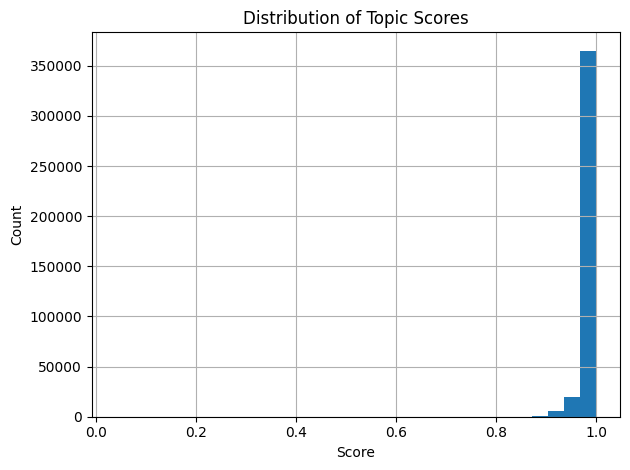

In [31]:
# Summary statistics
print(works_topics_df['score'].describe())

# Plot the distribution to visually check skew and decide on a score threshold
works_topics_df['score'].hist(bins=30)
plt.title("Distribution of Topic Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Most of the topic assignments have scores close to 1. This means that we are highly confident in the subfield assignments for these papers. We don't have to apply a score threshold to filter out papers who have weak subfields. 

---
## Step 5: Build Transactions
- Each paper is a transaction
- Each research subfield assigned to that paper is an item

We use subfield_name rather than topic_name because subfields appear frequently enough across papers to produce meaningful support values. Papers with fewer than 2 subfields are dropped since they cannot contribute to co-occurrence patterns.

In [23]:
# No score threshold applied
# so all assignments are included regardless of score
strong_topics_df = works_topics_df.copy()

# Group by paper 
# Each paper is assigned to its groups of subfields
work_topics = (
    strong_topics_df
    .groupby('work_id')['subfield_name']
    .apply(set)
)

# Drop papers with fewer than 2 subfields
work_topics = work_topics[work_topics.apply(len) >= 2]

print(f"Papers with >=2 subfields: {len(work_topics):,}")

# Convert to list-of-lists (mlxtend format)
transactions = [list(topics) for topics in work_topics]

print("\nSample transaction:")
print(transactions[0])

Papers with >=2 subfields: 121,357

Sample transaction:
['Experimental and Cognitive Psychology', 'Applied Psychology', 'Social Psychology']


---
## Step 6: Sample for Memory Efficiency
With many transactions, building a full boolean matrix would make the kernel crash. A random sample of 100,000 papers is enough to return meaningful data. 

In [24]:
import random

# 10k papers is enough 
SAMPLE_SIZE = 10_000 

# Fix the seed so re-running this cell gives the same sample every time
random.seed(42)
if len(transactions) > SAMPLE_SIZE:
    transactions = random.sample(transactions, SAMPLE_SIZE)

print(f"Working with {len(transactions):,} transactions")
print(f"Sample transaction: {transactions[0]}")

Working with 10,000 transactions
Sample transaction: ['Forestry', 'Molecular Biology', 'Nutrition and Dietetics']


---
## Step 7: Encode Transactions as a Boolean Matrix
TransactionEncoder converts the list-of-lists into a boolean DataFrame where:
- Rows = papers (transactions)
- Columns = unique subfields (items)
- Values = True if that subfield appears in that paper

In [25]:
# First learn all unique subfields, then one-hot encode each transaction
te = TransactionEncoder()
te_array = te.fit_transform(transactions)

# Wrap in a DataFrame
te_df = pd.DataFrame(te_array, columns=te.columns_)

print(f"Matrix shape: {te_df.shape}")
print(f"  {te_df.shape[0]:,} rows  (papers / transactions)")
print(f"  {te_df.shape[1]:,} cols  (unique subfields / items)")

sparsity = (~te_df).sum().sum() / te_df.size
print(f"\nSparsity: {sparsity:.3%} of values are False")
print(f"Column dtype (item keys): {te_df.columns.dtype}")

te_df.head(3)

Matrix shape: (10000, 227)
  10,000 rows  (papers / transactions)
  227 cols  (unique subfields / items)

Sparsity: 98.869% of values are False
Column dtype (item keys): str


,Accounting,Acoustics and Ultrasonics,Aerospace Engineering,Aging,Agronomy and Crop Science,Analytical Chemistry,Anesthesiology and Pain Medicine,Animal Science and Zoology,Anthropology,Applied Mathematics,...,Surgery,"Tourism, Leisure and Hospitality Management",Toxicology,Transplantation,Transportation,Urban Studies,Urology,Virology,Visual Arts and Performing Arts,Water Science and Technology
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


---
## Step 8: Running Apriori to Find Frequent Itemsets
Using Apriori finds all subfield combinations whose support meets our minimum threshold.

We use min_support = 0.0 (0.5% of papers). We chose 0.01 because it's enough to capture meaningful pairs without introducing much noise.

In [26]:
# a subfield or pair must appear in at least 1% of sampled papers
MIN_SUPPORT = 0.01 

print(f"Running Apriori (min_support={MIN_SUPPORT})...")
frequent_itemsets = apriori(
    te_df,
    min_support=MIN_SUPPORT,
    # label itemsets with subfield names, not column indices
    use_colnames=True,   
    verbose=1,
)

# Add a length column to easily filter singles, pairs, triples
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"Found {len(frequent_itemsets):,} frequent itemsets")

# Sort by length first, then by support descending within each length group
frequent_itemsets = frequent_itemsets.sort_values(
    ['length', 'support'], ascending=[True, False]
)

print("Frequent itemsets by size:")
print(frequent_itemsets['length'].value_counts().sort_index().to_string())

print("\nTop 10 frequent subfield PAIRS (length = 2):")
frequent_itemsets[frequent_itemsets['length'] == 2][['support', 'itemsets']].head(10)

Running Apriori (min_support=0.01)...
Processing 297 combinations | Sampling itemset size 32
Found 82 frequent itemsets
Frequent itemsets by size:
length
1    65
2    17

Top 10 frequent subfield PAIRS (length = 2):


,support,itemsets
81,0.0284,"frozenset({Renewable Energy, Sustainability and the Environment, Materials C..."
73,0.0280,"frozenset({Materials Chemistry, Electrical and Electronic Engineering})"
74,0.0280,"frozenset({Renewable Energy, Sustainability and the Environment, Electrical ..."
69,0.0170,"frozenset({Biomedical Engineering, Materials Chemistry})"
72,0.0166,"frozenset({Electronic, Optical and Magnetic Materials, Electrical and Electr..."
80,0.0163,"frozenset({Neurology, Infectious Diseases})"
71,0.0156,"frozenset({Molecular Biology, Cancer Research})"
66,0.0148,"frozenset({Automotive Engineering, Electrical and Electronic Engineering})"
65,0.0117,"frozenset({Artificial Intelligence, Computer Vision and Pattern Recognition})"
70,0.0116,"frozenset({Mechanical Engineering, Biomedical Engineering})"


In [27]:
# Testing five different support thresholds
for threshold in [0.005, 0.01, 0.02, 0.05, 0.1]:
    
    fi = apriori(te_df, min_support=threshold, use_colnames=True, verbose=0)
    print(f"min_support = {threshold:.3f}  →  {len(fi):>5,} frequent itemsets")

min_support = 0.005  →    167 frequent itemsets
min_support = 0.010  →     82 frequent itemsets
min_support = 0.020  →     46 frequent itemsets
min_support = 0.050  →      7 frequent itemsets
min_support = 0.100  →      3 frequent itemsets


We chose min_support = 0.01 as our threshold because it returns 82 meaningful subfield combinations. It isn't so low that we include noisy or rarely occurring pairs. It also isn't too high that we aren't able to find any meaningful patterns from a few itemsets.

---
## Step 9: Generate Association Rules

In [13]:
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    # only keep rules where lift > 1 (above-chance co-occurrence)
    min_threshold=1.0,         
    num_itemsets=len(frequent_itemsets),
)

print(f"Generated {len(rules):,} association rules")

# Sort by lift
# Highest lift = most surprising/interesting co-occurrences
rules.sort_values('lift', ascending=False).head(10)

Generated 32 association rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
27,frozenset({Industrial and Manufacturing Engineering}),frozenset({Pollution}),0.0291,0.0334,0.0106,0.364261,10.906023,1.0,0.009628,1.520436,0.935532,0.204239,0.342294,0.340813
26,frozenset({Pollution}),frozenset({Industrial and Manufacturing Engineering}),0.0334,0.0291,0.0106,0.317365,10.906023,1.0,0.009628,1.422283,0.939693,0.204239,0.296905,0.340813
17,frozenset({Computer Vision and Pattern Recognition}),frozenset({Artificial Intelligence}),0.0312,0.0554,0.0117,0.375000,6.768953,1.0,0.009972,1.511360,0.879714,0.156208,0.338344,0.293096
16,frozenset({Artificial Intelligence}),frozenset({Computer Vision and Pattern Recognition}),0.0554,0.0312,0.0117,0.211191,6.768953,1.0,0.009972,1.228181,0.902251,0.156208,0.185788,0.293096
28,frozenset({Immunology}),frozenset({Oncology}),0.0371,0.0481,0.0103,0.277628,5.771893,1.0,0.008515,1.317742,0.858601,0.137517,0.241126,0.245883
29,frozenset({Oncology}),frozenset({Immunology}),0.0481,0.0371,0.0103,0.214137,5.771893,1.0,0.008515,1.225278,0.868523,0.137517,0.183858,0.245883
10,frozenset({Neurology}),frozenset({Infectious Diseases}),0.0416,0.0712,0.0163,0.391827,5.503187,1.0,0.013338,1.527197,0.853805,0.168912,0.345206,0.310380
11,frozenset({Infectious Diseases}),frozenset({Neurology}),0.0712,0.0416,0.0163,0.228933,5.503187,1.0,0.013338,1.242952,0.881015,0.168912,0.195464,0.310380
12,frozenset({Molecular Biology}),frozenset({Cancer Research}),0.1265,0.0242,0.0156,0.123320,5.095874,1.0,0.012539,1.113063,0.920164,0.115470,0.101578,0.383974
13,frozenset({Cancer Research}),frozenset({Molecular Biology}),0.0242,0.1265,0.0156,0.644628,5.095874,1.0,0.012539,2.457988,0.823696,0.115470,0.593163,0.383974


From the 82 frequent itemsets found by Apriori, we generated 32 association rules by only keeping rules with a lift greater than 1. This means that the subfield pairs co-occur more often than chance would predict. 

The top result shows that Industrial and Manufacturing Engineering and Pollution are the most surprisingly linked subfields. Sorting by lift shows the most interesting co-occurrence patterns rather than just common ones. 

---
## Step 10: Add Symmetric Metrics

In [14]:
def cosine_metric(row):
    # Mean of the two directional confidences (symmetric)
    return row['support'] / (row['antecedent support'] * row['consequent support']) ** 0.5

def kulczynski_metric(row):
    conf_ac = row['confidence']                             # P(B | A)
    conf_ca = row['support'] / row['consequent support']   # P(A | B)
    return 0.5 * (conf_ac + conf_ca)                       # average of both directions

def jaccard_metric(row):
    union = row['antecedent support'] + row['consequent support'] - row['support']
    return row['support'] / union

# Apply both metrics to every rule
rules['cosine']     = rules.apply(cosine_metric, axis=1)
rules['jaccard']    = rules.apply(jaccard_metric, axis=1)
rules['kulczynski'] = rules.apply(kulczynski_metric, axis=1)

print("Top rules by Kulczynski (most robust symmetric metric):")
(
    rules
    .sort_values('kulczynski', ascending=False)
    [['antecedents', 'consequents', 'support', 'confidence', 'lift', 'cosine', 'jaccard', 'kulczynski']]
    .head(10)
)

Top rules by Kulczynski (most robust symmetric metric):


,antecedents,consequents,support,confidence,lift,cosine,jaccard,kulczynski
12,frozenset({Molecular Biology}),frozenset({Cancer Research}),0.0156,0.123320,5.095874,0.281950,0.115470,0.383974
13,frozenset({Cancer Research}),frozenset({Molecular Biology}),0.0156,0.644628,5.095874,0.281950,0.115470,0.383974
27,frozenset({Industrial and Manufacturing Engineering}),frozenset({Pollution}),0.0106,0.364261,10.906023,0.340006,0.204239,0.340813
26,frozenset({Pollution}),frozenset({Industrial and Manufacturing Engineering}),0.0106,0.317365,10.906023,0.340006,0.204239,0.340813
14,frozenset({Automotive Engineering}),frozenset({Electrical and Electronic Engineering}),0.0148,0.521127,4.206027,0.249498,0.107636,0.320289
15,frozenset({Electrical and Electronic Engineering}),frozenset({Automotive Engineering}),0.0148,0.119451,4.206027,0.249498,0.107636,0.320289
11,frozenset({Infectious Diseases}),frozenset({Neurology}),0.0163,0.228933,5.503187,0.299503,0.168912,0.310380
10,frozenset({Neurology}),frozenset({Infectious Diseases}),0.0163,0.391827,5.503187,0.299503,0.168912,0.310380
0,"frozenset({Renewable Energy, Sustainability and the Environment})",frozenset({Materials Chemistry}),0.0284,0.345079,3.114431,0.297405,0.172435,0.300698
1,frozenset({Materials Chemistry}),"frozenset({Renewable Energy, Sustainability and the Environment})",0.0284,0.256318,3.114431,0.297405,0.172435,0.300698


Confidence alone is not enough as it gives different scores depending on the direction of the rule (A -> B or B -> A). We add three symmetric metrics which are cosine, kulczynski, and jaccard which measure the relationships of rules going in both directions. 

The top result shows that Molecular Biology and Cancer Research have the strongest symmetric relationship.

---
## Step 11: Visualization — Top 15 Most Frequent Subfields
A horizontal bar chart of the 15 subfields with the highest individual support. The chart shows which research areas appear most often among highly-cited papers. Bars are annotated with exact support values.

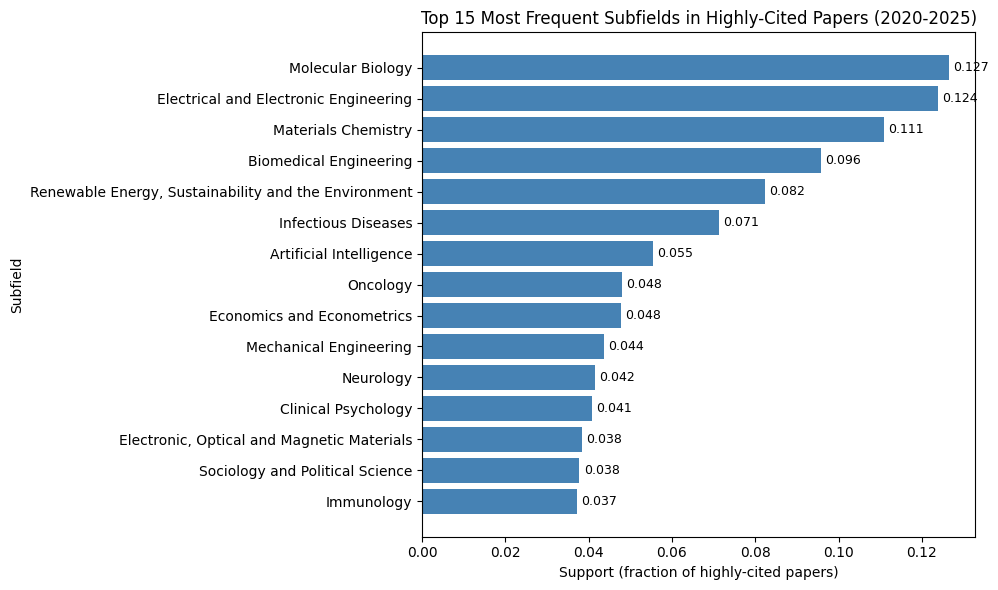

In [15]:
# Get single-item itemsets and pull the subfield name out of the frozenset
top_singles = (
    frequent_itemsets[frequent_itemsets['length'] == 1]
    .copy()
)
top_singles['subfield'] = top_singles['itemsets'].apply(lambda x: list(x)[0])
top_singles = top_singles.sort_values('support', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_singles['subfield'], top_singles['support'], color='steelblue')

# Annotate each bar with its exact support value
for bar, val in zip(bars, top_singles['support']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel("Support (fraction of highly-cited papers)")
ax.set_ylabel("Subfield")
ax.set_title("Top 15 Most Frequent Subfields in Highly-Cited Papers (2020-2025)")
ax.invert_yaxis()  # highest support at the top
plt.tight_layout()
plt.show()

The top 3 subfields all exceed 10% support, which shows that biology and engineering research make up a large amount of highly-cited works between 2020 and 2025. 

---
## Step 12: Visualization — Frequent Subfield Pairs
A bar chart of all frequent pairs of subfields. Each bar represents a combination of two subfields that co-appear in at least 1% of highly-cited papers.

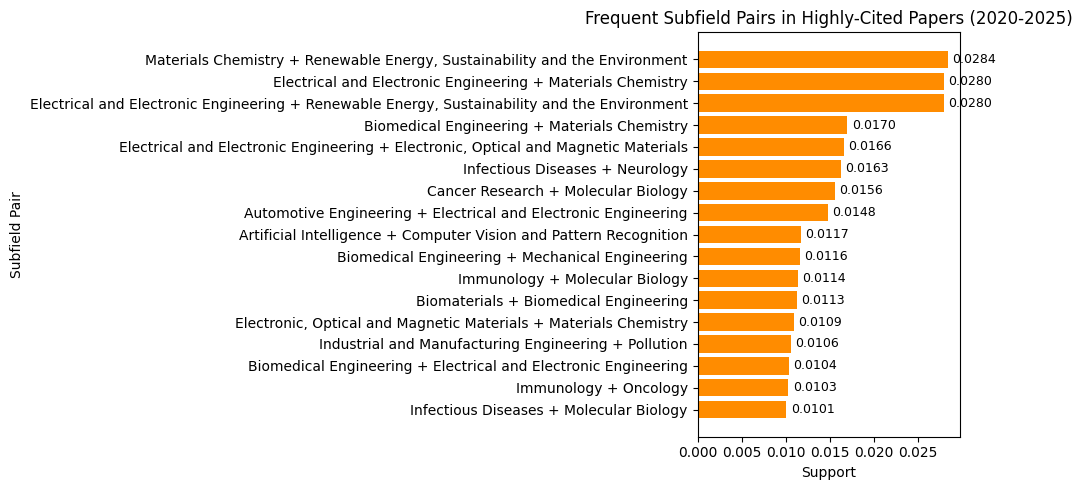

In [16]:
# Get length 2 itemsets and format each pair
pairs = (
    frequent_itemsets[frequent_itemsets['length'] == 2]
    .copy()
)
pairs['pair'] = pairs['itemsets'].apply(lambda x: ' + '.join(sorted(list(x))))
pairs = pairs.sort_values('support', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(pairs['pair'], pairs['support'], color='darkorange')

# Annotate each bar with its exact support value
for bar, val in zip(bars, pairs['support']):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel("Support")
ax.set_ylabel("Subfield Pair")
ax.set_title("Frequent Subfield Pairs in Highly-Cited Papers (2020-2025)")
ax.invert_yaxis()  # most frequent pair at the top
plt.tight_layout()
plt.show()

The top three pairs all involve Renewable Energy, Sustainability, and the Environment or Materials Chemistry, which suggests that clean energy and materials research appear together frequently. 

---
## Step 13: Visualization — Scatter Plots

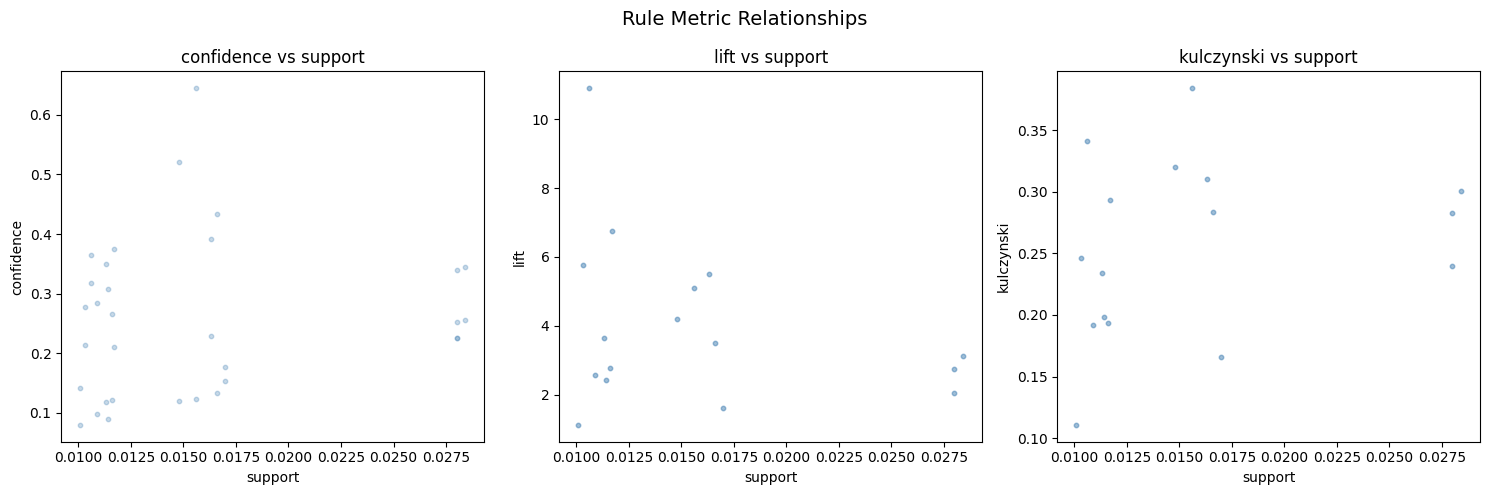

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, y_metric in zip(axes, ['confidence', 'lift', 'kulczynski']):
    ax.scatter(rules['support'], rules[y_metric],
               alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel('support')
    ax.set_ylabel(y_metric)
    ax.set_title(f'{y_metric} vs support')

plt.suptitle("Rule Metric Relationships", fontsize=14)
plt.tight_layout()
plt.show()

The three scatter plots show how confidence, lift, and kulczynski each relate to support across all 32 rules. 

High lift and high confidence don't really go together with high support as the highest lift (11) and the highest confidence (0.65) both belong to low support rules around 0.01. This means that the most surprising and strong co-occurrences are rare pairings.

The kulczynski plot also shows the same thing, which confirms that the most symmetrically strong relationships tend to appear less often.

---
## Step 14: Interpret Top Rules
Print the most interesting rules ranked by lift and confidence.

- High lift = the two subfields co-occur far more than chance
- High confidence = when the antecedent subfield appears, the consequent almost always does too

In [18]:
def fmt_set(s):
    # Convert a frozenset of subfield names into a readable string
    return ', '.join(sorted(s))

# Build the top 15 rules sorted by kulczynski 
top_rules = (
    rules
    .sort_values('kulczynski', ascending=False)
    .head(15)
    # Include all metrics for comparison
    [['antecedents', 'consequents', 'support', 'confidence',
      'lift', 'cosine', 'jaccard', 'kulczynski']]
    .reset_index(drop=True)
    .copy()
)

# Convert frozensets to readable strings so the table is readable
top_rules['antecedents'] = top_rules['antecedents'].apply(fmt_set)
top_rules['consequents'] = top_rules['consequents'].apply(fmt_set)

# Create a styled table 
# Blue gradient highlights strongest lift and kulczynski values (most interesting)
# Format each metric column to a consistent number of decimal places
top_rules.style.background_gradient(
    subset=['lift', 'kulczynski'], cmap='Blues'
).format({
    'support':    '{:.4f}',  
    'confidence': '{:.3f}',
    'lift':       '{:.2f}',
    'cosine':     '{:.3f}',
    'jaccard':    '{:.3f}',
    'kulczynski': '{:.3f}',
})

,antecedents,consequents,support,confidence,lift,cosine,jaccard,kulczynski
0,Molecular Biology,Cancer Research,0.0156,0.123,5.10,0.282,0.115,0.384
1,Cancer Research,Molecular Biology,0.0156,0.645,5.10,0.282,0.115,0.384
2,Industrial and Manufacturing Engineering,Pollution,0.0106,0.364,10.91,0.340,0.204,0.341
3,Pollution,Industrial and Manufacturing Engineering,0.0106,0.317,10.91,0.340,0.204,0.341
4,Automotive Engineering,Electrical and Electronic Engineering,0.0148,0.521,4.21,0.249,0.108,0.320
5,Electrical and Electronic Engineering,Automotive Engineering,0.0148,0.119,4.21,0.249,0.108,0.320
6,Infectious Diseases,Neurology,0.0163,0.229,5.50,0.300,0.169,0.310
7,Neurology,Infectious Diseases,0.0163,0.392,5.50,0.300,0.169,0.310
8,"Renewable Energy, Sustainability and the Environment",Materials Chemistry,0.0284,0.345,3.11,0.297,0.172,0.301
9,Materials Chemistry,"Renewable Energy, Sustainability and the Environment",0.0284,0.256,3.11,0.297,0.172,0.301
